In [1]:
!pip install -U tokenizers transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!git clone https://github.com/apache/tika.git && cd tika && git checkout b6bcce634

Cloning into 'tika'...
remote: Enumerating objects: 244987, done.
remote: Counting objects: 100% (1126/1126), done.
remote: Compressing objects: 100% (523/523), done.
remote: Total 244987 (delta 733), reused 630 (delta 507), pack-reused 243861 (from 3)
Receiving objects: 100% (244987/244987), 356.40 MiB | 11.93 MiB/s, done.
Resolving deltas: 100% (97405/97405), done.
Updating files: 100% (4368/4368), done.
Note: switching to 'b6bcce634'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at b6bcce634 TIKA-4327: updat

**0. Import requireed modules**

In [3]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
import csv
# ...

**1. Provide the path of java files and load their source code into a list**

In [4]:
SOURCE_CODE_DIR = Path("/content/tika/tika-core/src/main/java")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# focused_rsf_path = Path("/content/drive/MyDrive/dsse_arcade_outputs/tika-focused.rsf")
# classes_set = set()
# with open(focused_rsf_path, mode="r") as f:
#   for line in f:
#     rsf_contents = line.split(" ")
#     classes_set.update(rsf_contents[1:])
# cleaned_class_list = []
# class_list = list(classes_set)
# cleaned_class_list = [line.strip() for line in class_list if line.strip()]
# cleaned_class_list = list(set(cleaned_class_list))
# cleaned_class_list.sort()

In [ ]:
# files_list = []
# # .rglob() searches the root folder and all sub-folders automatically
# for file_path in SOURCE_CODE_DIR.rglob('*.java'):
#     if file_path.is_file():
#         with open(file_path, 'r', encoding='utf-8') as f:
#             files_list.append(f.read())

In [16]:
cleaned_class_list = []

for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    path_str = str(file_path.as_posix()) # Ensure forward slashes

    if file_path.is_file() and ("org/apache/tika/detect" in path_str or "org/apache/tika/parser" in path_str):
        relative_path = path_str.split("src/main/java/")[1]

        class_name = relative_path.replace("/", ".").replace(".java", "")
        cleaned_class_list.append(class_name)

cleaned_class_list.sort()

In [17]:
len(cleaned_class_list)

64

In [18]:
cleaned_class_list

['org.apache.tika.detect.AutoDetectReader',
 'org.apache.tika.detect.BOMDetector',
 'org.apache.tika.detect.CharsetSupersets',
 'org.apache.tika.detect.CompositeDetector',
 'org.apache.tika.detect.CompositeEncodingDetector',
 'org.apache.tika.detect.DefaultDetector',
 'org.apache.tika.detect.DefaultEncodingDetector',
 'org.apache.tika.detect.DefaultProbDetector',
 'org.apache.tika.detect.DetectHelper',
 'org.apache.tika.detect.Detector',
 'org.apache.tika.detect.EmptyDetector',
 'org.apache.tika.detect.EncodingDetector',
 'org.apache.tika.detect.EncodingDetectorContext',
 'org.apache.tika.detect.EncodingResult',
 'org.apache.tika.detect.FileCommandDetector',
 'org.apache.tika.detect.MagicDetector',
 'org.apache.tika.detect.MetaEncodingDetector',
 'org.apache.tika.detect.MetadataCharsetDetector',
 'org.apache.tika.detect.NNExampleModelDetector',
 'org.apache.tika.detect.NNTrainedModel',
 'org.apache.tika.detect.NNTrainedModelBuilder',
 'org.apache.tika.detect.NameDetector',
 'org.apache

In [19]:
with open(Path("/content/class_index.csv"), "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Index", "Class Name"])
    for index, class_name in enumerate(cleaned_class_list):
        writer.writerow([index, class_name])

In [21]:
def path_rewriter(java_class):
  class_path = Path(f"/content/tika/tika-core/src/main/java/{java_class.replace(".","/")}.java")
  return class_path

class_filepath = [path_rewriter(class_path) for class_path in cleaned_class_list]
# print(type(class_filepath[0]))
# print(class_filepath[0])
# len(class_filepath)

In [ ]:
# files_list = []
# # .rglob() searches the root folder and all sub-folders automatically
# for file_path in SOURCE_CODE_DIR.rglob('*.java'):
#     if file_path.is_file():
#         with open(file_path, 'r', encoding='utf-8') as f:
#             files_list.append(f.read())

In [23]:
# Using alternative list
files_list = []
# .rglob() searches the root folder and all sub-folders automatically
for file_path in class_filepath:
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())
    else:
      print(f"File {file_path} not found")
      files_list.append("")

In [24]:
len(files_list)

64

In [54]:
#SANITY CHECK
print(f"File 0 length: {len(files_list[0])} characters")
print(f"File 1 length: {len(files_list[1])} characters")
print(f"File 20 length: {len(files_list[20])} characters")

if files_list[0] == files_list[1]:
    print("CRITICAL BUG: The files are identical. Check the file reading loop.")
else:
    print("Files are unique. The bug is in the embedding model math.")

File 0 length: 5726 characters
File 1 length: 4327 characters
File 20 length: 1999 characters
Files are unique. The bug is in the embedding model math.


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [27]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import userdata

In [28]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [29]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [30]:
embedding_model_name = "nomic-ai/nomic-embed-code"

In [12]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token)
model = AutoModel.from_pretrained(embedding_model_name,token=hf_token,quantization_config=bnb_config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/25.7k [00:00<?, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Qwen2Model(
  (embed_tokens): Embedding(152064, 3584)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear4bit(in_features=3584, out_features=3584, bias=True)
        (k_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (v_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (o_proj): Linear4bit(in_features=3584, out_features=3584, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (up_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (down_proj): Linear4bit(in_features=18944, out_features=3584, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((3584,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

**5. Construct the semantic similarity matrix**

In [56]:
def last_token_pooling(hidden_states, attention_mask):
    sequence_lengths = attention_mask.sum(-1) - 1
    return hidden_states[torch.arange(hidden_states.shape[0]), sequence_lengths]

def embed_source_code(code_files):
    embeddings = []
    for i, code in enumerate(code_files):
        # Max length 512 (for current model and available memory size)
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            model_output = outputs.last_hidden_state
            vector = last_token_pooling(model_output, inputs['attention_mask'])
            vector = vector.squeeze(0).cpu().numpy()

        embeddings.append(vector)
    return np.vstack(embeddings)

In [57]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

In [58]:
print(embeddings.shape)
print(semantic_matrix.shape)

(64, 3584)
(64, 64)


In [59]:
tokenizer.padding_side

'right'

In [62]:
np.save(Path('/content/drive/MyDrive/embeddings.npy'), embeddings)
np.save(Path('/content/drive/MyDrive/semantic_matrix.npy'), semantic_matrix)

In [46]:
semantic_matrix_test = np.load(Path('/content/drive/MyDrive/semantic_similarity_matrix.npy'), mmap_mode=None, allow_pickle=True)
embeddings = np.load(Path('/content/drive/MyDrive/embeddings.npy'), mmap_mode=None, allow_pickle=True)
semantic_matrix = np.load(Path('/content/drive/MyDrive/semantic_matrix.npy'), mmap_mode=None, allow_pickle=True)

In [43]:
semantic_matrix.shape

(64, 64)

In [60]:
semantic_matrix

array([[0.99999994, 0.5073575 , 0.32492936, ..., 0.23424956, 0.27898192,
        0.15726015],
       [0.5073575 , 1.        , 0.34891504, ..., 0.29207116, 0.25214258,
        0.2696505 ],
       [0.32492936, 0.34891504, 1.0000002 , ..., 0.16616209, 0.2712325 ,
        0.15764107],
       ...,
       [0.23424956, 0.29207116, 0.16616209, ..., 0.9999999 , 0.61844575,
        0.41496328],
       [0.27898192, 0.25214258, 0.2712325 , ..., 0.61844575, 1.        ,
        0.35032186],
       [0.15726015, 0.2696505 , 0.15764107, ..., 0.41496328, 0.35032186,
        1.0000001 ]], dtype=float32)

In [47]:
semantic_matrix_test

array([[1.        , 0.84339535, 0.95176905, ..., 0.83504164, 0.808964  ,
        0.8145707 ],
       [0.84339535, 1.        , 0.81933856, ..., 0.81395257, 0.79001164,
        0.78974545],
       [0.95176905, 0.81933856, 1.0000002 , ..., 0.8215096 , 0.8035335 ,
        0.8044755 ],
       ...,
       [0.83504164, 0.81395257, 0.8215096 , ..., 1.        , 0.95778584,
        0.96365255],
       [0.808964  , 0.79001164, 0.8035335 , ..., 0.95778584, 1.        ,
        0.96596766],
       [0.8145707 , 0.78974545, 0.8044755 , ..., 0.96365255, 0.96596766,
        1.0000002 ]], dtype=float32)

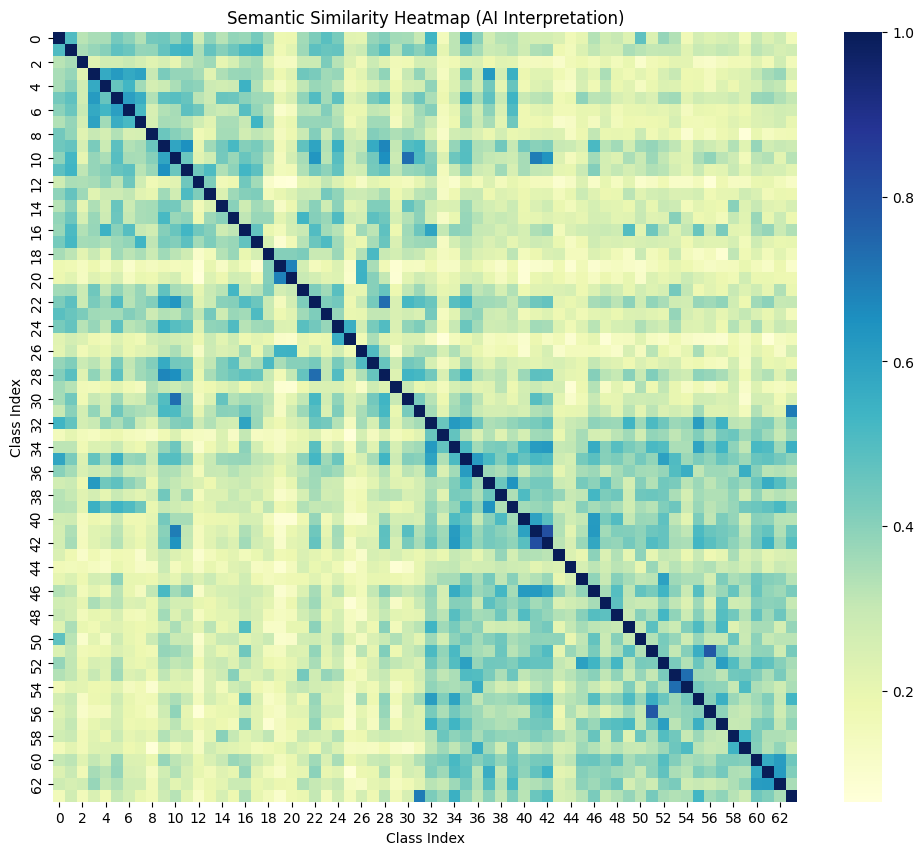

<Figure size 640x480 with 0 Axes>

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# Using a different color map (YlGnBu) helps distinguish the gradients
sns.heatmap(semantic_matrix, cmap="YlGnBu")
plt.title("Semantic Similarity Heatmap (AI Interpretation)")
plt.xlabel("Class Index")
plt.ylabel("Class Index")
plt.show()
plt.savefig("/content/drive/MyDrive/semantic_heatmap.png", dpi=300)

In [36]:
# # NOT NEEDED
# import numpy as np

# semantic_stretched = semantic_matrix.copy()

# off_diag_indices = np.where(~np.eye(semantic_matrix.shape[0], dtype=bool))
# off_diag_values = semantic_matrix[off_diag_indices]

# p_low = np.percentile(off_diag_values, 5)
# p_high = np.percentile(off_diag_values, 95)

# print(f"Stretching Blob: {p_low:.4f} -> {p_high:.4f}")

# semantic_stretched = (semantic_matrix - p_low) / (p_high - p_low)
# semantic_stretched = np.clip(semantic_stretched, 0, 1)

# np.fill_diagonal(semantic_stretched, 1.0)

In [53]:
semantic_matrix.shape

(64, 64)

In [51]:
print(embeddings[0])

[-1.122939    0.69376695 -0.77143514 ...  2.1282232   0.36934754
 -0.8939236 ]


In [ ]:
# semantic_stretched.shape

(159, 159)

In [52]:
# semantic_matrix = semantic_stretched

**6. Construct the structural similarity matrix**

In [83]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'
focused_rsf_path = Path("/content/drive/MyDrive/dsse_arcade_outputs/tika-focused.rsf")
class_to_index = {name: i for i, name in enumerate(cleaned_class_list)}
struct_matrix_raw = np.zeros((len(cleaned_class_list), len(cleaned_class_list)))
edges_mapped = 0

with open(focused_rsf_path, mode="r") as f:
    for line in f:
        rsf_contents = line.strip().split(" ")
        # print(src,dest)
        src, dest = rsf_contents[1].split('$')[0], rsf_contents[2].split('$')[0]
        if src in class_to_index and dest in class_to_index:
           i = class_to_index[src]
           j = class_to_index[dest]

           # Mark the connection
          #  print(f"connection: {src} to {dest}")
           struct_matrix_raw[i][j] = 1
           edges_mapped += 1
#np.fill_diagonal(struct_matrix_raw, 1.0) #THIS IS FOR SELF-SIMILARITY -- DONE LATER

In [76]:
edges_mapped

204

In [77]:
print(struct_matrix_raw)

[[1. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


In [78]:
struct_matrix_raw.shape

(64, 64)

In [84]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 10))
# sns.heatmap(struct_matrix_raw, cmap="Blues", cbar=False)
# plt.title("Structural Dependency Heatmap (Tika Core)")
# plt.xlabel("Target Class Index")
# plt.ylabel("Source Class Index")
# plt.show()

In [85]:
np.save(Path('/content/drive/MyDrive/struct_matrix_raw.npy'), struct_matrix_raw)

**7. Normalize the structural matrix**

In [86]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

In [88]:
np.save(Path('/content/drive/MyDrive/struct_matrix.npy'), struct_matrix)

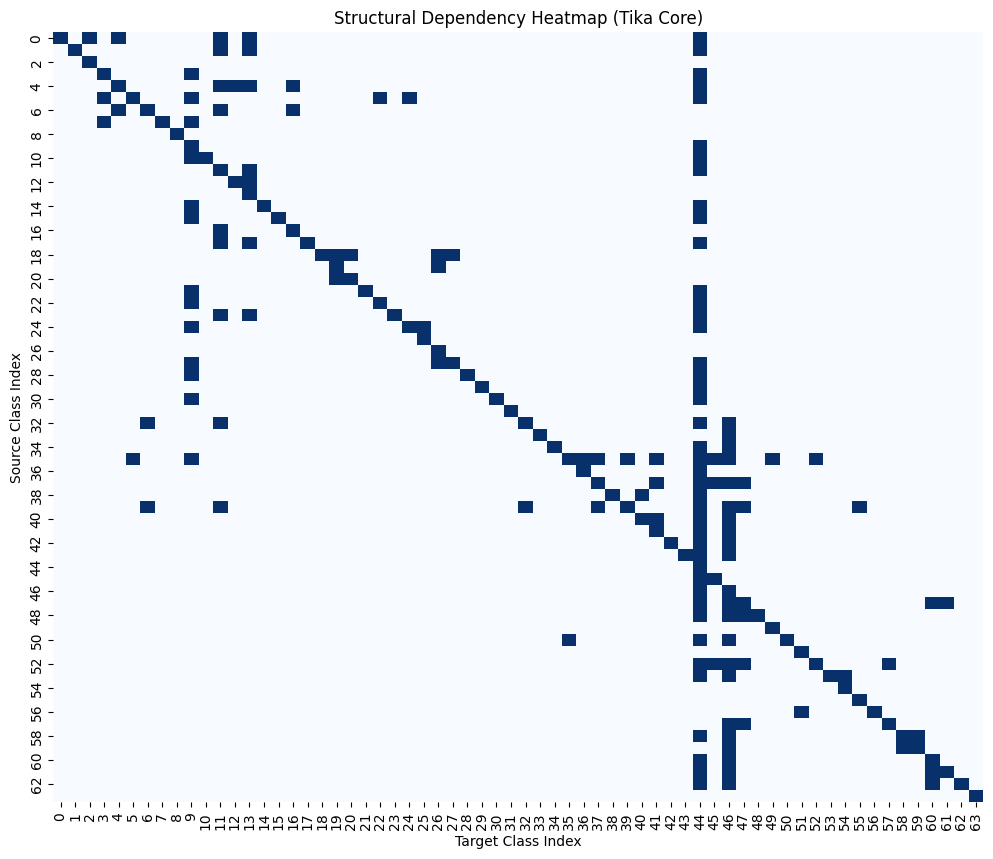

<Figure size 640x480 with 0 Axes>

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(struct_matrix, cmap="Blues", cbar=False)
plt.title("Structural Dependency Heatmap (Tika Core)")
plt.xlabel("Target Class Index")
plt.ylabel("Source Class Index")
plt.show()
plt.savefig("/content/drive/MyDrive/struct_heatmap.png", dpi=300)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [107]:
ALPHA = 0.4
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Ensure similarity values are within [0, 1] before converting to distance
combined_similarity = np.clip(combined_similarity, 0.0, 1.0)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

In [105]:
semantic_matrix

array([[0.99999994, 0.5073575 , 0.32492936, ..., 0.23424956, 0.27898192,
        0.15726015],
       [0.5073575 , 1.        , 0.34891504, ..., 0.29207116, 0.25214258,
        0.2696505 ],
       [0.32492936, 0.34891504, 1.0000002 , ..., 0.16616209, 0.2712325 ,
        0.15764107],
       ...,
       [0.23424956, 0.29207116, 0.16616209, ..., 0.9999999 , 0.61844575,
        0.41496328],
       [0.27898192, 0.25214258, 0.2712325 , ..., 0.61844575, 1.        ,
        0.35032186],
       [0.15726015, 0.2696505 , 0.15764107, ..., 0.41496328, 0.35032186,
        1.0000001 ]], dtype=float32)

In [103]:
struct_matrix

array([[1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

/tmp/ipykernel_1115/2478629968.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


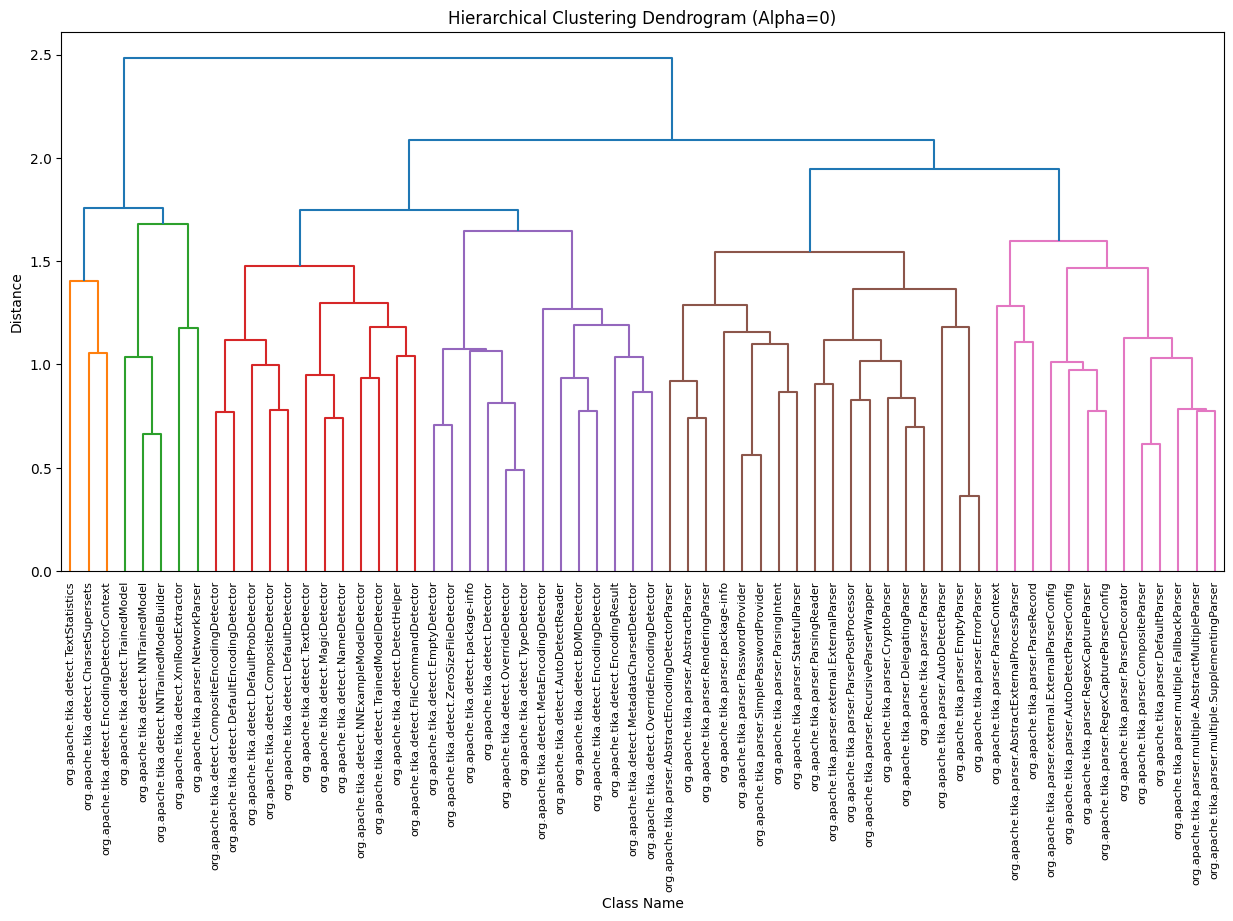

In [97]:
# USING 0 ALPHA
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 7))
dendrogram(Z, labels=cleaned_class_list, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Hierarchical Clustering Dendrogram (Alpha={ALPHA})")
plt.xlabel("Class Name")
plt.ylabel("Distance")
plt.show()

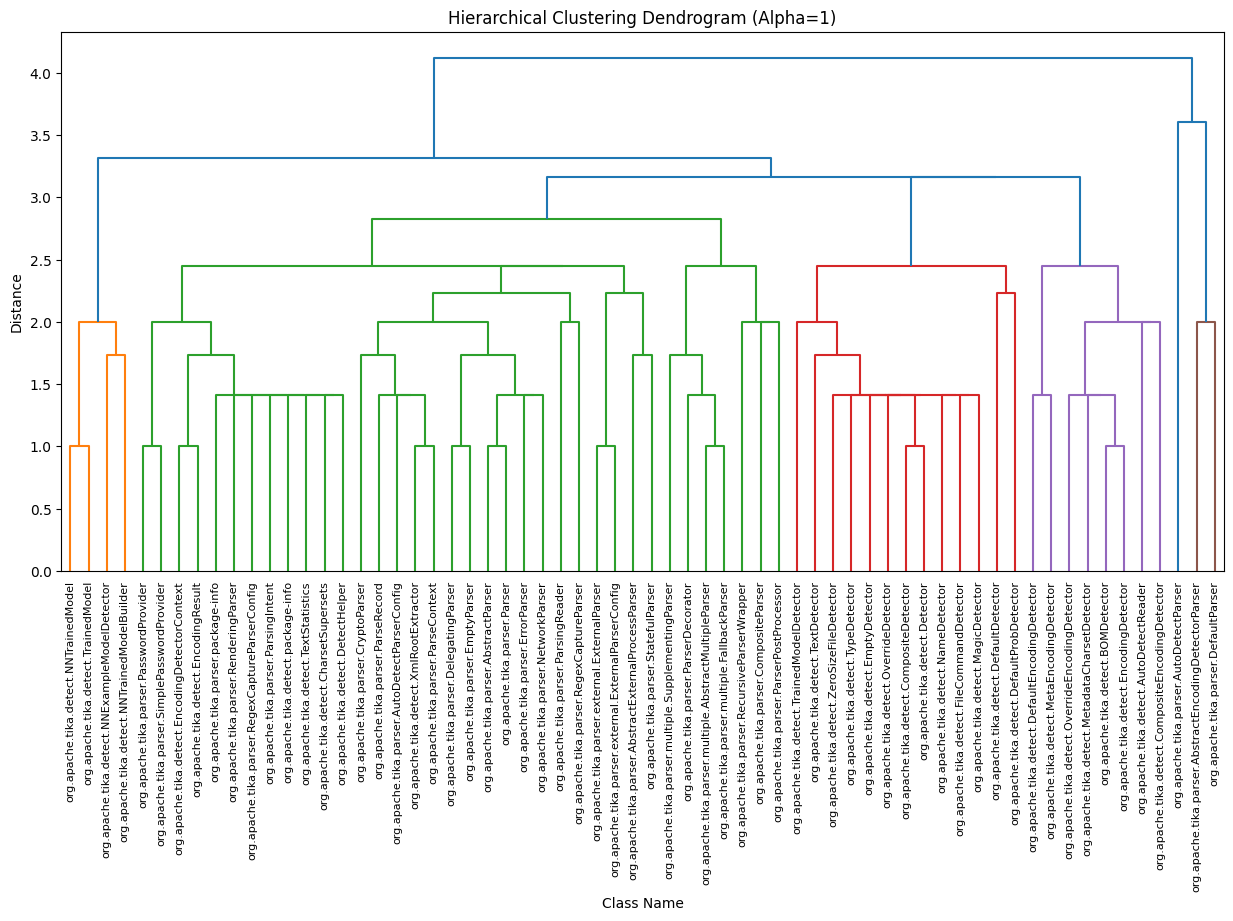

In [99]:
# USING 1 ALPHA
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 7))
dendrogram(Z, labels=cleaned_class_list, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Hierarchical Clustering Dendrogram (Alpha={ALPHA})")
plt.xlabel("Class Name")
plt.ylabel("Distance")
plt.show()

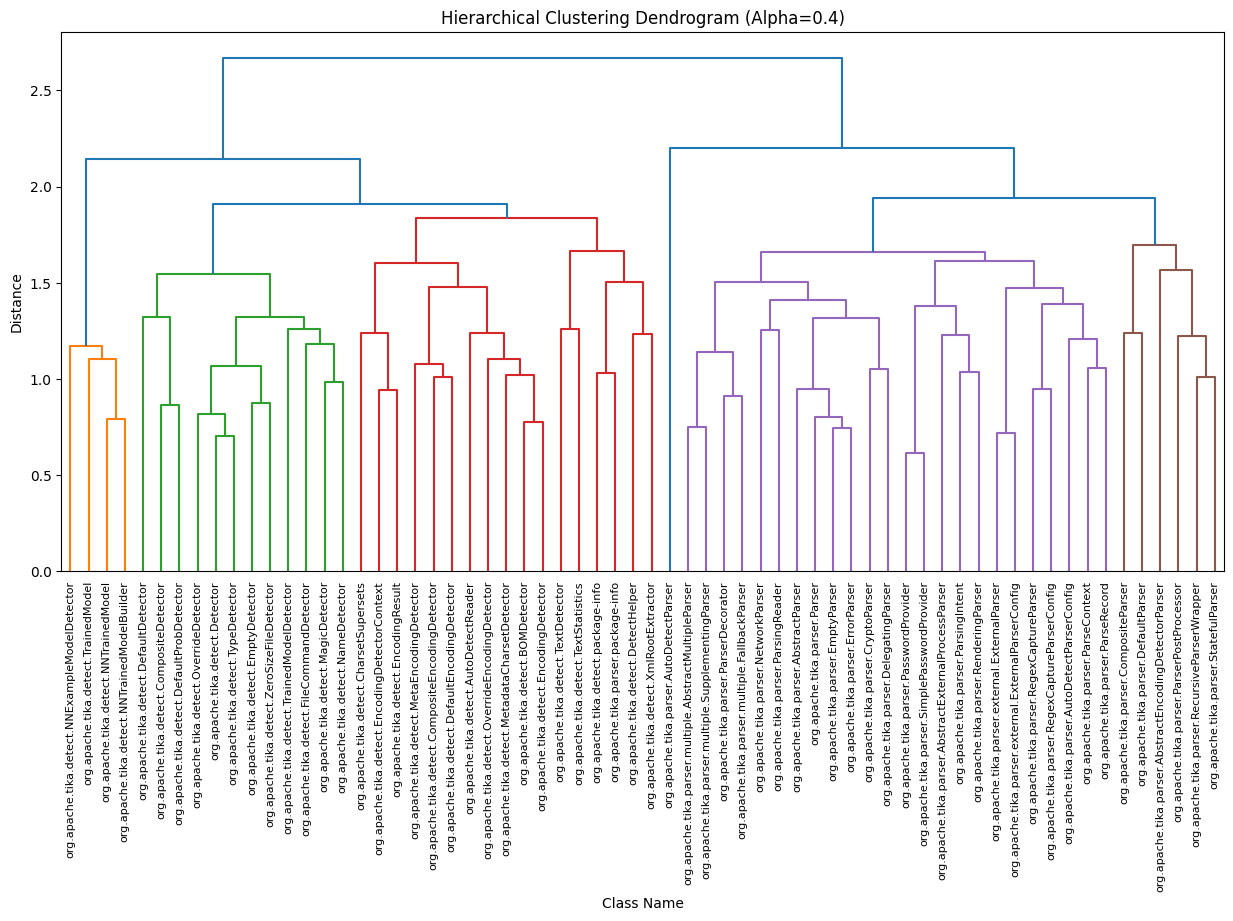

<Figure size 640x480 with 0 Axes>

In [115]:
# USING 0.4 ALPHA
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 7))
dendrogram(Z, labels=cleaned_class_list, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Hierarchical Clustering Dendrogram (Alpha={ALPHA})")
plt.xlabel("Class Name")
plt.ylabel("Distance")
plt.show()
plt.savefig("/content/drive/MyDrive/arc_clustering_dendogram.png", dpi=300)

**9. Apply clustering**

In [109]:
# Silhouette_score for optimal number of clusters between 0 and 20
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Define the sensible range of clusters for a 64-class system
min_clusters = 5
max_clusters = 20

best_score = -1.0
best_k = 10
scores = []

print("Evaluating cluster counts (k)...")

# 2. Test every possible cluster count
for k in range(min_clusters, max_clusters + 1):
    # Run the clustering for this 'k'
    clusterer = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='complete')
    temp_labels = clusterer.fit_predict(distance_matrix)

    # Calculate the mathematical quality of these clusters
    # Note: We must pass metric='precomputed' to the scorer as well
    score = silhouette_score(distance_matrix, temp_labels, metric='precomputed')
    scores.append(score)

    print(f"k={k}: Silhouette Score = {score:.4f}")

    # Save the best one
    if score > best_score:
        best_score = score
        best_k = k

# 3. Apply the mathematically proven optimum
print(f"OPTIMAL CLUSTER COUNT FOUND: {best_k} (Score: {best_score:.4f})")

TARGET_NUM_CLUSTERS = best_k

# 4. Generate your final, optimal ARC clusters
final_clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete')
clusters = final_clusterer.fit_predict(distance_matrix)

Evaluating cluster counts (k)...
k=5: Silhouette Score = 0.1091
k=6: Silhouette Score = 0.1073
k=7: Silhouette Score = 0.1130
k=8: Silhouette Score = 0.0945
k=9: Silhouette Score = 0.1081
k=10: Silhouette Score = 0.1027
k=11: Silhouette Score = 0.1031
k=12: Silhouette Score = 0.1072
k=13: Silhouette Score = 0.0929
k=14: Silhouette Score = 0.1014
k=15: Silhouette Score = 0.1182
k=16: Silhouette Score = 0.1202
k=17: Silhouette Score = 0.0987
k=18: Silhouette Score = 0.0938
k=19: Silhouette Score = 0.0783
k=20: Silhouette Score = 0.0797
OPTIMAL CLUSTER COUNT FOUND: 16 (Score: 0.1202)


In [110]:
TARGET_NUM_CLUSTERS = 16 # how such parameter could be optimized?
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete') # what is 'precomputed' & 'linkage'?
clusters = clusterer.fit_predict(distance_matrix)

In [113]:
arc_output_path = "/content/drive/MyDrive/tika-arc.rsf"

# Write the cluster mappings to the RSF file
with open(arc_output_path, "w") as f:
    for idx, class_name in enumerate(cleaned_class_list):
        cluster_id = clusters[idx]

        # Format explicitly required for Week 4:
        # contain Cluster_X org.apache.tika.parser.Parser
        f.write(f"contain Cluster_{cluster_id} {class_name}\n")

print(f"Success! Optimal ARC clusters saved to: {arc_output_path}")

print("\n--- Output Preview ---")
with open(arc_output_path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

Success! Optimal ARC clusters saved to: /content/drive/MyDrive/tika-arc.rsf

--- Output Preview ---
contain Cluster_15 org.apache.tika.detect.AutoDetectReader
contain Cluster_9 org.apache.tika.detect.BOMDetector
contain Cluster_15 org.apache.tika.detect.CharsetSupersets
contain Cluster_1 org.apache.tika.detect.CompositeDetector
contain Cluster_12 org.apache.tika.detect.CompositeEncodingDetector


In [111]:
import pandas as pd

# Create a summary table
cluster_summary = pd.Series(clusters).value_counts().sort_index().reset_index()
cluster_summary.columns = ['Cluster ID', 'File Count']
cluster_summary['Percentage'] = (cluster_summary['File Count'] / len(clusters)) * 100

print(cluster_summary.to_string(index=False))

 Cluster ID  File Count  Percentage
          0           8     12.5000
          1           7     10.9375
          2           5      7.8125
          3           3      4.6875
          4           5      7.8125
          5           6      9.3750
          6           4      6.2500
          7           3      4.6875
          8           5      7.8125
          9           5      7.8125
         10           1      1.5625
         11           2      3.1250
         12           4      6.2500
         13           2      3.1250
         14           2      3.1250
         15           2      3.1250


In [112]:
clusters

array([15,  9, 15,  1, 12,  1, 12,  1,  4,  1,  4,  9, 12,  9,  4,  1, 12,
        9,  2,  2,  2,  1,  1,  9, 13, 13,  2,  2,  4, 10,  4, 11,  0,  3,
        0,  5,  5,  8,  7,  0,  0,  0,  5,  7,  0,  6,  0,  8,  6,  5,  7,
        5,  6, 14, 14,  0,  5,  6,  3,  3,  8,  8,  8, 11])

**10. Visulizations**

In [ ]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.